#### Plot monthly wave flux @ PacWave

In [1]:
import mhkit
from mhkit.wave import resource, performance, graphics, contours
from sklearn.mixture import GaussianMixture
from mhkit.wave.io import ndbc
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy import stats
import pandas as pd
import numpy as np
import folium
import os

import matplotlib.pylab as pylab

params = {
    "legend.fontsize": "x-large",
    "figure.figsize": (15, 5),
    "axes.labelsize": "x-large",
    "axes.titlesize": "x-large",
    "xtick.labelsize": "x-large",
    "ytick.labelsize": "x-large",
}
pylab.rcParams.update(params)

In [2]:
m = folium.Map(
    location=[44.613600975457715, -123.74317583354498],
    zoom_start=9,
    tiles="OpenStreetMap",
    attr="Map data © OpenStreetMap contributors",
    control_scale=True,
)

tooltip = "NDBC 46050"
folium.Marker(
    [44.669, -124.546], popup="<i> Water depth: 160 m</i>", tooltip=tooltip
).add_to(m)

tooltip = "PACWAVE North"
folium.Marker(
    [44.69, -124.13472222222222],
    tooltip=tooltip,
    icon=folium.Icon(color="green", icon="th-large"),
).add_to(m)

tooltip = "PACWAVE South"
folium.Marker(
    [44.58444444444444, -124.2125],
    tooltip=tooltip,
    icon=folium.Icon(color="red", icon="th"),
).add_to(m)

m.save("index.png")

m

In [3]:
# # Get buoy metadata
# buoy_number = "46050"
# buoy_metadata = ndbc.get_buoy_metadata(buoy_number)
# print("Buoy Metadata:")
# for key, value in buoy_metadata.items():
#     print(f"{key}: {value}")

In [4]:
# Spectral wave density for buoy 46050
buoy_number = "46050"
parameter = "swden"

# Request list of available files#
ndbc_available_data = ndbc.available_data(parameter, buoy_number)

# Pass file names to NDBC and request the data
filenames = ndbc_available_data["filename"]
ndbc_requested_data = ndbc.request_data(parameter, filenames)

ndbc_requested_data["2020"]

,#YY,MM,DD,hh,mm,.0200,.0325,.0375,.0425,.0475,...,.3300,.3400,.3500,.3650,.3850,.4050,.4250,.4450,.4650,.4850
0,2020,1,1,0,40,0.0,0.0,0.00,2.28,2.99,...,0.19,0.22,0.15,0.12,0.12,0.06,0.04,0.03,0.02,0.02
1,2020,1,1,1,40,0.0,0.0,0.37,3.30,3.12,...,0.20,0.15,0.14,0.14,0.07,0.05,0.04,0.02,0.03,0.01
2,2020,1,1,2,40,0.0,0.0,0.00,4.80,5.16,...,0.07,0.18,0.14,0.10,0.13,0.08,0.04,0.02,0.01,0.01
3,2020,1,1,3,40,0.0,0.0,0.00,1.70,1.38,...,0.30,0.14,0.11,0.08,0.10,0.03,0.03,0.03,0.01,0.00
4,2020,1,1,4,40,0.0,0.0,0.24,5.72,7.90,...,0.12,0.18,0.07,0.10,0.12,0.04,0.03,0.03,0.02,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8616,2020,12,31,19,40,0.0,0.0,0.00,0.00,0.00,...,0.11,0.08,0.08,0.08,0.03,0.02,0.01,0.01,0.01,0.01
8617,2020,12,31,20,40,0.0,0.0,0.00,0.00,0.99,...,0.07,0.10,0.06,0.06,0.05,0.04,0.03,0.03,0.01,0.01
8618,2020,12,31,21,40,0.0,0.0,0.00,0.00,0.01,...,0.05,0.06,0.06,0.06,0.04,0.03,0.03,0.02,0.01,0.01
8619,2020,12,31,22,40,0.0,0.0,0.00,0.00,0.93,...,0.10,0.09,0.09,0.10,0.04,0.03,0.02,0.02,0.01,0.01


In [5]:
ndbc_data = {}
# Create a Datetime Index and remove NOAA date columns for each year
for year in ndbc_requested_data:
    year_data = ndbc_requested_data[year]
    ndbc_data[year] = ndbc.to_datetime_index(parameter, year_data)

ndbc_data["2020"]

,0.0200,0.0325,0.0375,0.0425,0.0475,0.0525,0.0575,0.0625,0.0675,0.0725,...,0.3300,0.3400,0.3500,0.3650,0.3850,0.4050,0.4250,0.4450,0.4650,0.4850
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:40:00,0.0,0.0,0.00,2.28,2.99,0.00,0.00,2.91,7.23,10.65,...,0.19,0.22,0.15,0.12,0.12,0.06,0.04,0.03,0.02,0.02
2020-01-01 01:40:00,0.0,0.0,0.37,3.30,3.12,0.94,1.49,3.13,8.58,12.09,...,0.20,0.15,0.14,0.14,0.07,0.05,0.04,0.02,0.03,0.01
2020-01-01 02:40:00,0.0,0.0,0.00,4.80,5.16,0.66,1.44,4.19,14.32,26.21,...,0.07,0.18,0.14,0.10,0.13,0.08,0.04,0.02,0.01,0.01
2020-01-01 03:40:00,0.0,0.0,0.00,1.70,1.38,0.00,0.47,2.91,15.89,32.12,...,0.30,0.14,0.11,0.08,0.10,0.03,0.03,0.03,0.01,0.00
2020-01-01 04:40:00,0.0,0.0,0.24,5.72,7.90,2.75,0.59,4.39,17.49,18.75,...,0.12,0.18,0.07,0.10,0.12,0.04,0.03,0.03,0.02,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 19:40:00,0.0,0.0,0.00,0.00,0.00,6.15,21.06,28.97,21.23,20.75,...,0.11,0.08,0.08,0.08,0.03,0.02,0.01,0.01,0.01,0.01
2020-12-31 20:40:00,0.0,0.0,0.00,0.00,0.99,5.20,21.62,26.23,27.02,32.43,...,0.07,0.10,0.06,0.06,0.05,0.04,0.03,0.03,0.01,0.01
2020-12-31 21:40:00,0.0,0.0,0.00,0.00,0.01,0.58,6.02,21.26,18.66,13.60,...,0.05,0.06,0.06,0.06,0.04,0.03,0.03,0.02,0.01,0.01


In [6]:
# Intialize empty lists to store the results from each year
Hm0_list = []
Te_list = []
J_list = []
Tp_list = []
Tz_list = []

# Iterate over each year and save the result in the initalized dictionary
for year in ndbc_data:
    data_raw = ndbc_data[year]
    year_data = data_raw[data_raw != 999.0].dropna()
    Hm0_list.append(resource.significant_wave_height(year_data.T))
    Te_list.append(resource.energy_period(year_data.T))
    J_list.append(resource.energy_flux(year_data.T, h=399.0))

    # Tp_list.append(resource.peak_period(year_data.T))
    fp = year_data.T.idxmax(axis=0)
    Tp = 1/fp
    Tp = pd.DataFrame(Tp, index=year_data.T.columns, columns=["Tp"])
    Tp_list.append(Tp)

    Tz_list.append(resource.average_zero_crossing_period(year_data.T))

# Concatenate each list of Series into a single Series
Te = pd.concat(Te_list, axis=0)
Tp = pd.concat(Tp_list, axis=0)
Hm0 = pd.concat(Hm0_list, axis=0)
J = pd.concat(J_list, axis=0)
Tz = pd.concat(Tz_list, axis=0)

# Name each Series and concat into a dataFrame
Te.name = 'Te'
Tp.name = 'Tp'
Hm0.name = 'Hm0'
J.name = 'J'
Tz.name = 'Tz'
data = pd.concat([Hm0, Te, Tp, J, Tz], axis=1)

# Calculate wave steepness
data["Sm"] = data.Hm0 / (9.81 / (2 * np.pi) * data.Tz**2)

# Drop any NaNs created from the calculation of Hm0 or Te
data.dropna(inplace=True)
# Sort the DateTime index
data.sort_index(inplace=True)

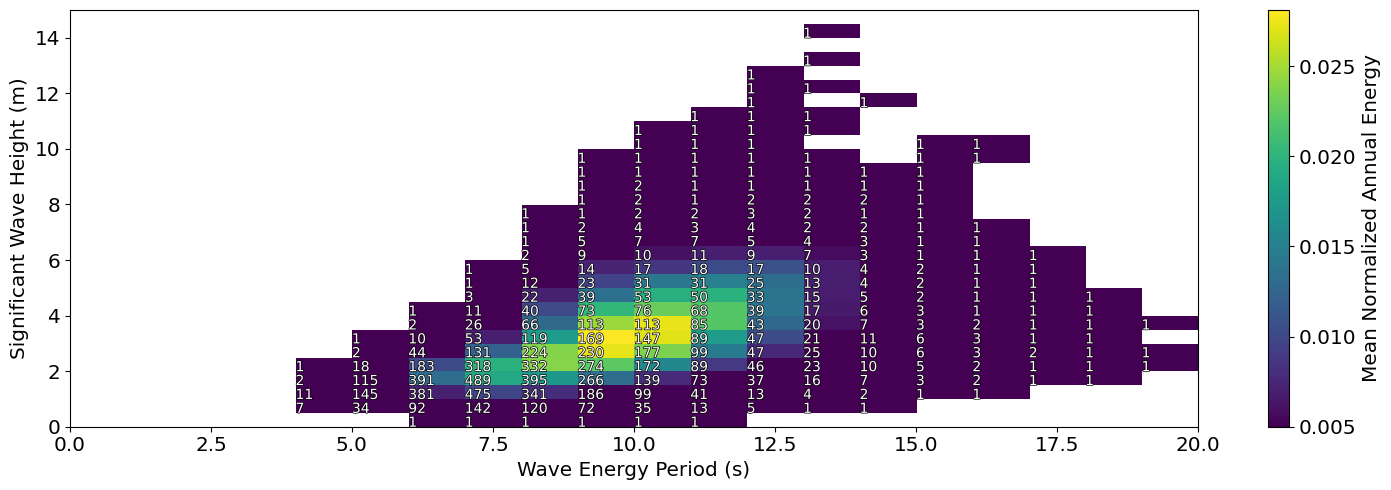

In [7]:
# Start by cleaning the data of outliers
data_clean = data[data.Hm0 < 20]
sigma = data_clean.J.std()
data_clean = data_clean[data_clean.J > (data_clean.J.mean() - 0.9 * sigma)]

# Organizing the cleaned data
Hm0 = data_clean.Hm0
Te = data_clean.Te
J = data_clean.J

# Setting the bins for the resource frequency and power distribution
Hm0_bin_size = 0.5
Hm0_edges = np.arange(0, 15 + Hm0_bin_size, Hm0_bin_size)
Te_bin_size = 1
Te_edges = np.arange(0, 20 + Te_bin_size, Te_bin_size)

fig = mhkit.wave.graphics.plot_avg_annual_energy_matrix(
    Hm0, Te, J, Hm0_edges=Hm0_edges, Te_edges=Te_edges
)

--------------------------------------------
Hm0 max:3.0424, month: 12
Hm0 min:1.426, month: 8
--------------------------------------------
Te max:10.3586, month: 1
Te min:7.0789, month: 7
--------------------------------------------
Tp max:12.5, month: 1
Tp min:8.3333, month: 7
--------------------------------------------
J max:45919.3605, month: 1
J min:7061.094, month: 8
--------------------------------------------
Tz max:7.9985, month: 1
Tz min:5.6727, month: 7
--------------------------------------------
Sm max:0.0318, month: 12
Sm min:0.0265, month: 9


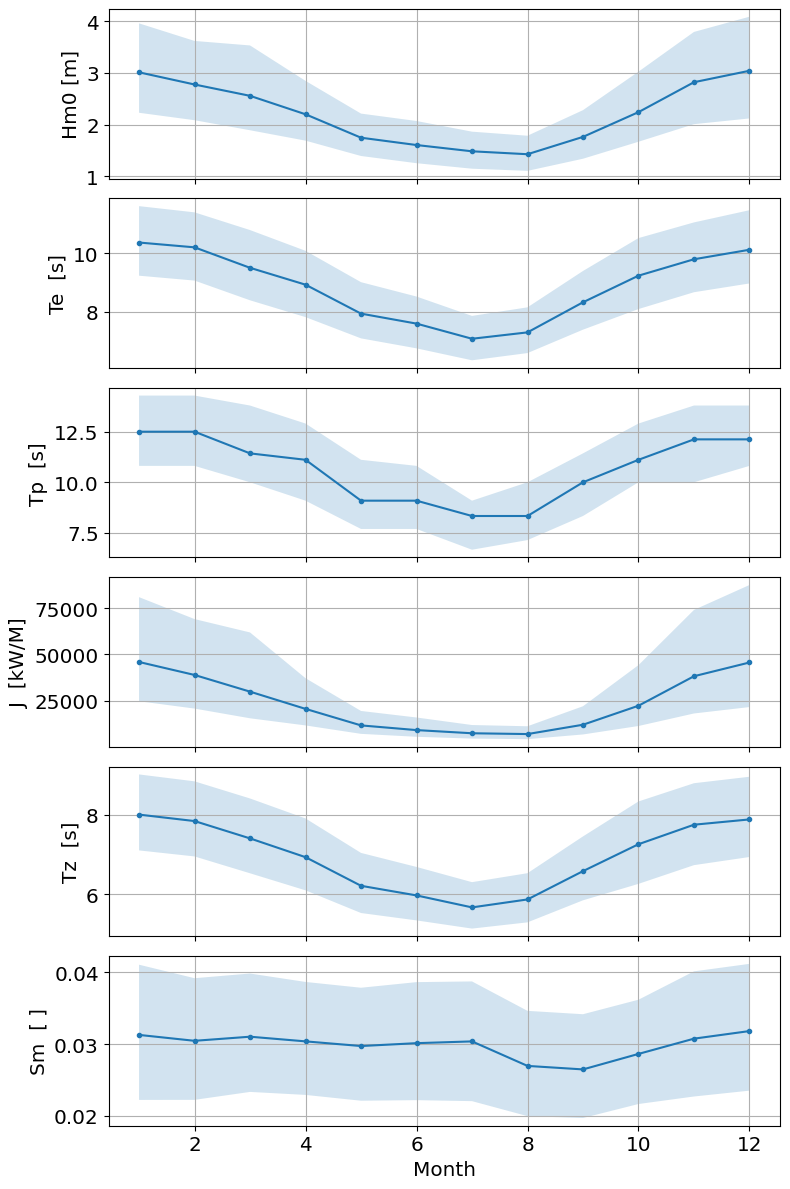

In [8]:
months = data_clean.index.month
data_group = data_clean.groupby(months)

QoIs = data_clean.keys()
fig, axs = plt.subplots(len(QoIs), 1, figsize=(8, 12), sharex=True)
# shade between 25% and 75%
QoIs = data_clean.keys()
for i in range(len(QoIs)):
    QoI = QoIs[i]
    axs[i].plot(data_group.median()[QoI], marker=".")

    axs[i].fill_between(
        months.unique(),
        data_group.describe()[QoI, "25%"],
        data_group.describe()[QoI, "75%"],
        alpha=0.2,
    )
    axs[i].grid()
    mx = data_group.median()[QoI].max()
    mx_month = data_group.median()[QoI].argmax() + 1
    mn = data_group.median()[QoI].min()
    mn_month = data_group.median()[QoI].argmin() + 1
    print("--------------------------------------------")
    print(f"{QoI} max:{np.round(mx,4)}, month: {mx_month}")
    print(f"{QoI} min:{np.round(mn,4)}, month: {mn_month}")

plt.setp(axs[5], xlabel="Month")

plt.setp(axs[0], ylabel=f"{QoIs[0]} [m]")
plt.setp(axs[1], ylabel=f"{QoIs[1]}  [s]")
plt.setp(axs[2], ylabel=f"{QoIs[2]}  [s]")
plt.setp(axs[3], ylabel=f"{QoIs[3]}  [kW/M]")
plt.setp(axs[4], ylabel=f"{QoIs[4]}  [s]")
plt.setp(axs[5], ylabel=f"{QoIs[5]}  [ ]")


plt.tight_layout()

plt.savefig("Delicious-Style.png")